In [1]:
script = False
cluster = False

In [2]:
# general
import numpy as np
from numpy.ma import masked_array
import pandas as pd
import random
import os
import gc

# images & plotting
from astropy.io import fits# general
import numpy as np
from numpy.ma import masked_array
import pandas as pd
import random
import os
import gc

# images & plotting
from astropy.io import fits
from astropy.visualization import make_lupton_rgb
from astropy.table import Table

# pytorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

# albumentations transformations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# loading bar
if not cluster:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as plticker
    plt.style.use('dark_background')
from astropy.visualization import make_lupton_rgb
from astropy.table import Table

# pytorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

# albumentations transformations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# loading bar
if not cluster:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as plticker
    plt.style.use('dark_background')

In [3]:
class Dataset(Dataset):
    """
    PyTorch dataset of images and data
    Args:
        * images {(N, channels, pix, pix) array}: images for dataset
        * data {pandas dataframe}: data for images
        * resize: composed albumentations augmentation to resize images
                  and masks to correct size (96, 96) & tensor
    Returns: Pytorch dataset
    """

    def __init__(self, images, data, resize=None):
        super().__init__()
        self.images = images
        self.data = data
        self.resize = resize

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # get image
        image = self.normalize(img)
        data_point = self.data.iloc[idx].to_dict()  # get data

        # transpose to appropriate dimensions
        image = image.transpose(1, 2, 0)  # (pix, pix, channels)

        # resizing transformation
        if self.resize is not None:
            resized = self.resize(image=image)
            image = resized['image']
        
        # return item
        return {'image': image, 'img': img, 'data': data_point}

    def normalize(self, image):
        """
        Normalize image between 0 and 1 using min and max
        Args:
        * image: (3, pix, pix) numpy array
        Returns: normalized image in original size
        """
        normed = np.empty(image.shape)  # break
        MIN = np.min(image)
        MAX = np.max(image)
        for band in range(3):
            flat = image[band].flatten(order='C')
            for i in range(len(flat)):
                flat[i] = (flat[i]-MIN)/(MAX-MIN)

            normed[band] = np.reshape(flat, image[0].shape, order='C')

        return normed

In [4]:
def show_dataset(dataset, idx):
    """
    Plot training dataset with transformations for visualization
    Args:
        * train_dataset: instance of ImageDataset for training
    Returns: void
    """
    sample = dataset[idx]
    original, transformed = sample['img'], sample['image']

    # set up figure
    fig, ax = plt.subplots(figsize=(8, 4), ncols=2)

    # original image
    orig_rgb = make_lupton_rgb(original[2], original[1], original[0], Q=11., stretch=40.)
    ax[0].set_title('Original Image')
    ax[0].xaxis.set_ticklabels([])
    ax[0].yaxis.set_ticklabels([])
    ax[0].imshow(orig_rgb, aspect='equal')

    # transformed image
    new_rgb = make_lupton_rgb(transformed[2], transformed[1], transformed[0], stretch=.5, Q=4.)
    ax[1].set_title('Transformed Image')
    ax[1].xaxis.set_ticklabels([])
    ax[1].yaxis.set_ticklabels([])
    ax[1].imshow(new_rgb, aspect='equal')

    if not script:
        plt.show()
        plt.close()

In [5]:
# set path name
# if cluster:
#     path = '/home/gcartwright/Segmentation/Image_Segmentation/' # OSG home
# else:
path = '/Users/jimenagonzalez/research/DSPL/Hybrid_SL_Modeling/data/candidates_data/' # local

num_workers = 0  # number of available CPUs
num_classes = 4

# get data from fits file
hdu_list = fits.open(path + 'mycand.fits')
images = hdu_list[1].data[:, 0:3]  # only want g,r,i bands not z
data = pd.DataFrame(hdu_list[2].data[:])
hdu_list.close()

data_complete = pd.read_csv(path + 'mycand_old.csv')
data_complete = (data_complete.set_index('COADD_OBJECT_ID').loc[data['COADD_OBJECT_ID']].reset_index())
data = data_complete

npos = len(images[:])  # number of images TESTING

data = data[data['EXP_SCORE'] > 2.5]
images = images[data.index]
data = data.reset_index(drop=True)

# check that data was loaded successfully
print(images.shape)
pd.set_option('display.max_columns', None)
data.head()

(89, 3, 45, 45)


,COADD_OBJECT_ID,TILENAME,RA,DEC,EXP_SCORE,FLUX_RADIUS_G,FLUX_RADIUS_R,FLUX_RADIUS_I,KRON_RADIUS,MAG_AUTO_G,MAG_AUTO_R,MAG_AUTO_I,MOF_BDF_G_1,MOF_BDF_G_2,MOF_BDF_T,EXT_COADD,MAG_APER_4_G,MAG_APER_4_R,MAG_APER_4_I
0,1032630238,DES0002-3332,0.818284,-33.801233,2.676636,9.348762,6.749952,5.750351,3.842526,21.382627,20.133585,19.212091,-2.120171e-01,9.401590e-02,1.002063e+01,3,23.468189,21.513172,20.409477
1,1040460697,DES0005-0124,1.215560,-1.055098,2.545379,4.589739,3.739490,3.420565,3.500000,22.422718,21.021170,20.416351,1.768080e-03,1.175570e-01,2.122239e+00,3,23.531261,21.786116,21.083759
2,1065068829,DES0023-4957,6.294487,-49.774042,2.717224,9.599688,6.428184,5.878614,3.979383,22.226660,20.657169,19.580198,-5.089870e-02,2.357457e-01,4.645942e+00,3,23.955511,22.024139,20.847019
3,1079483541,DES0033-2541,8.780600,-25.449639,2.832958,3.704973,3.185348,2.798992,3.500000,23.165855,21.814434,20.750956,-9.999000e+09,-9.999000e+09,-9.999000e+09,3,23.923983,22.359558,21.169121
4,1054556683,DES0016-4623,3.928374,-46.603077,3.000000,10.443616,10.139961,9.645621,3.627430,20.134268,18.785427,18.181929,-1.322807e-01,7.117598e-02,3.100975e+01,3,22.442060,20.631298,19.971987


In [6]:
NUM_PIX = 45  # number of pixels per axis

# Resize transformation
resize_transform = A.Compose([A.Resize(96, 96), ToTensorV2()])

reverse_resize = A.Compose([A.Resize(NUM_PIX, NUM_PIX)])


Length of dataset: 89


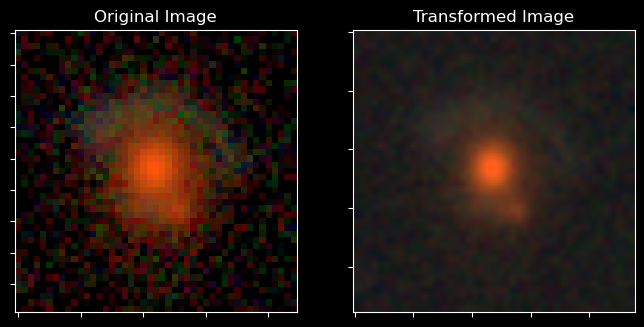

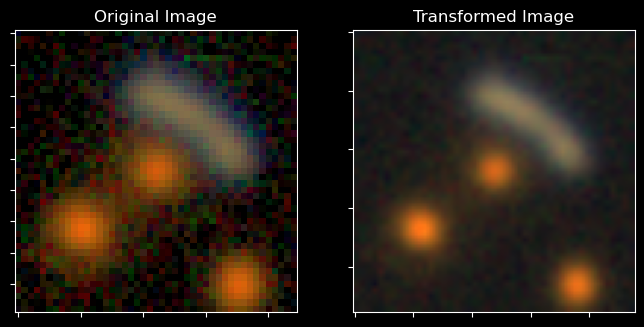

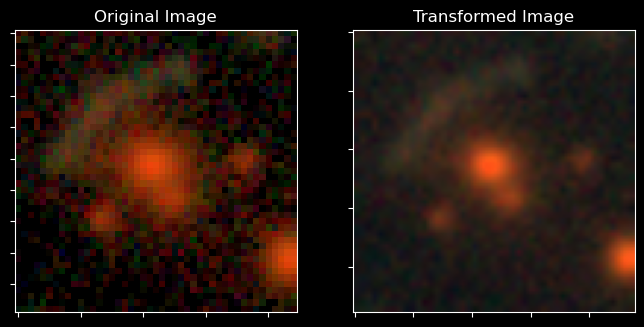

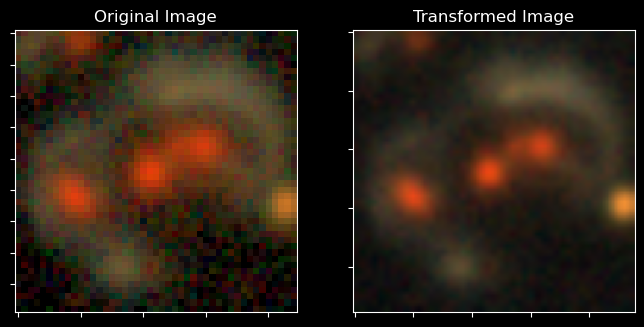

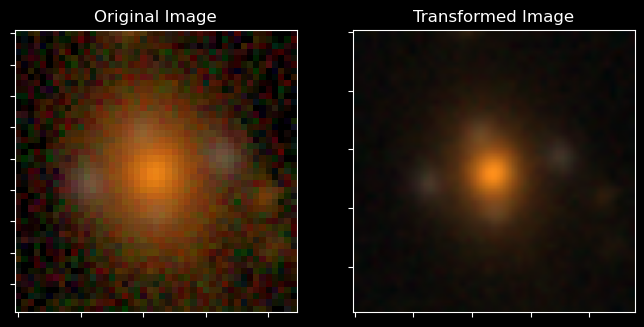

In [7]:
test_dataset = Dataset(images=images, data=data, resize=resize_transform)

# check datasets
print(f'Length of dataset: {len(test_dataset)}')

if script == False:
    for i in range(5):
        show_dataset(test_dataset, i)

In [8]:
# set up dataloaders
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=1, num_workers=num_workers, shuffle=True)
torch.save(test_loader, 'test_loader.pth')

In [9]:
def make_graphs(image, pred_label, coadd_id):
    loc = plticker.MultipleLocator(base=3.75)
    fig, ax = plt.subplots(figsize=(8, 4), ncols=2)

    rgb = make_lupton_rgb(image[2], image[1], image[0], Q=11., stretch=40.)
    ax[0].set_title('Image')
    ax[0].axis('off')
    ax[0].imshow(rgb, aspect='equal')
    
    # predicted label
    ax[1].set_title('Predicted Label')
    ax[1].imshow(pred_label[0, :, :], interpolation='nearest', cmap='magma')  # source
    ax[1].imshow(pred_label[1, :, :], alpha=0.5, interpolation='bilinear', cmap='spring')  # lens
    ax[1].imshow(pred_label[2, :, :], alpha=0.5, interpolation='bilinear', cmap='cool') # noise
    ax[1].axis('off')

    plt.savefig(f"data_masks/{coadd_id}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [10]:
def testing_analysis(accu_lim, test_loader, num):
    model.double()
    segmented = np.zeros((1, 4, NUM_PIX, NUM_PIX))
    originals = np.zeros((1, 3, NUM_PIX, NUM_PIX))
    df = data.head(1)

    for i_batch, sample in enumerate(test_loader):
        if(i_batch == num): break
        sample_image, sample_img, sample_data = sample['image'], sample['img'], sample['data']
        if device.type == "cuda":
            sample_image = sample_image.cuda()

        output = model(sample_image)
        output = torch.softmax(output, dim=1)
        output = output[0].cpu().detach().numpy()
        
        # reverse resize transformation
        output = np.transpose(output, (1, 2, 0))  # shape must be (pix, pix, 3)     
        resized = reverse_resize(image=output)
        output = resized['image']
        output = np.transpose(output, (2, 0, 1))  # turn back into (3, pix, pix)

        original_img = sample_img[0].detach().numpy()

        segmented = np.append(segmented, [output], axis=0)
        originals = np.append(originals, [original_img], axis=0)
        df = pd.concat([df, pd.DataFrame.from_dict(sample_data)], ignore_index=True)

        print(originals.shape, segmented.shape)
        #print(output.shape, original_img. shape)
        coadd_id = sample['data']['COADD_OBJECT_ID'][0].item()
        filepath = 'Output_running/' + str(coadd_id)
        write_fit_file(filepath, original_img, output, pd.DataFrame.from_dict(sample_data))
        
        if script == False:
            print(coadd_id)
            make_graphs(sample_img[0], output, coadd_id)

    segmented = np.delete(segmented, 0, axis=0)
    originals = np.delete(originals, 0, axis=0)
    df = df.drop(0, axis=0)
    return originals, segmented, df

In [11]:
class UNet(nn.Module):
    """
    U-Net model
    """
    def __init__(self, classes, pretrained=False): 
        super(UNet, self).__init__()

        if(not cluster):
            self.model = smp.Unet(encoder_name="resnet50", encoder_weights="imagenet", in_channels=3, classes=classes)
            torch.save(self.model.state_dict(), 'initial_model.pt')

        else:
            self.model = smp.Unet(encoder_name="resnet50", in_channels=3, classes=classes)
            self.model.load_state_dict(torch.load('initial_model.pt'))
            #model = UNet(classes=..., pretrained=...)   # same args as training
            #model.load_state_dict(torch.load("model.pt", map_location="cpu"))

    def forward(self, x):
        x = self.model(x)
        return x


In [12]:
def write_fit_file(name, images, labels, data):
    """
    writes fits file with simulation data, simulation images, and mask images
    """
    my_types = {'COADD_OBJECT_ID': int, 'TILENAME': str, 'RA': float, 'DEC': float, 'EXP_SCORE': float,
       'FLUX_RADIUS_G': float, 'FLUX_RADIUS_R': float, 'FLUX_RADIUS_I': float, 'KRON_RADIUS': float,
       'MAG_AUTO_G': float, 'MAG_AUTO_R': float, 'MAG_AUTO_I': float, 'MOF_BDF_G_1': float, 'MOF_BDF_G_2': float,
       'MAG_APER_4_I': float}
    data = data.astype(my_types)
    
    primary = fits.PrimaryHDU()
    image1 = fits.ImageHDU(images, name="IMAGE")  # original images: complete_sim, only source, only real deflector image
    image2 = fits.ImageHDU(labels, name="IMAGE")  # segmentation maps: source, deflector, noise, background
    table_data = Table.from_pandas(data)
    table = fits.BinTableHDU(data = table_data)
    hdu_list = fits.HDUList([primary, image1, image2, table])
    hdu_list.writeto(name + '_2.fits', overwrite=True)   
    hdu_list.close()



(2, 3, 45, 45) (2, 4, 45, 45)
1015396778


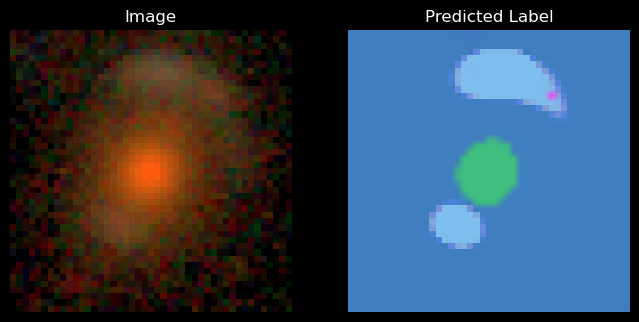

(3, 3, 45, 45) (3, 4, 45, 45)
1466401262


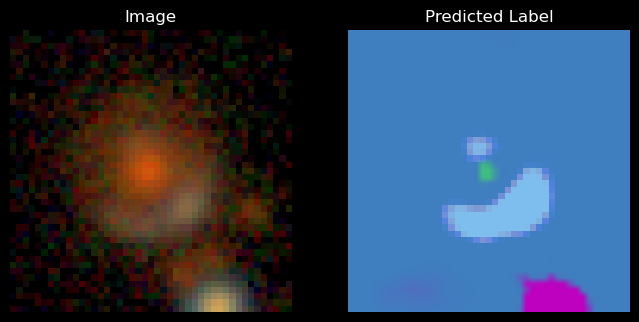

(4, 3, 45, 45) (4, 4, 45, 45)
1385113597


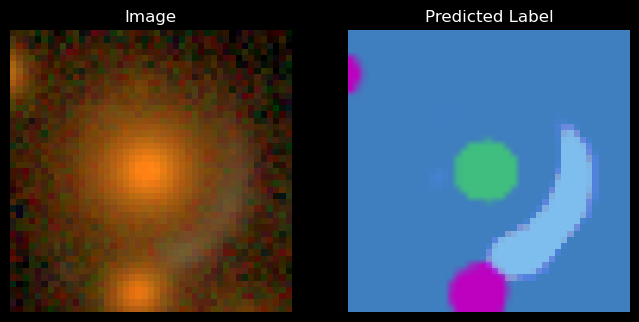

(5, 3, 45, 45) (5, 4, 45, 45)
913936319


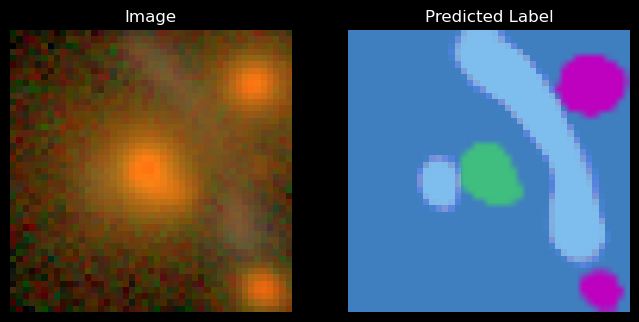

(6, 3, 45, 45) (6, 4, 45, 45)
919882930


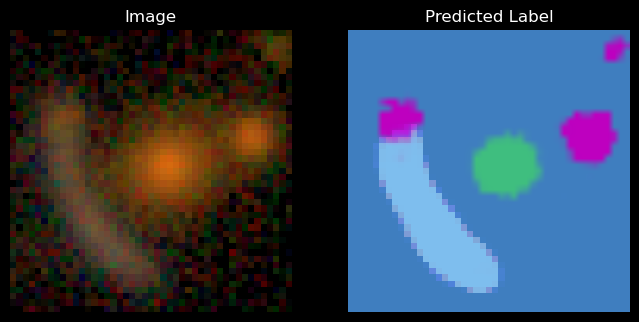

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load("Exp/model_exp6/model_tmp.pt", map_location=device)
model = UNet(classes=num_classes, pretrained=True).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()
test_loader = torch.load('test_loader.pth', weights_only=False)

num = 5 #len(test_loader)
original_img, segmented, df = testing_analysis(0.5, test_loader, num)
#Writing one fit file for all 
write_fit_file('data/test', original_img, segmented, df) #b_segmented
plt.close('all')



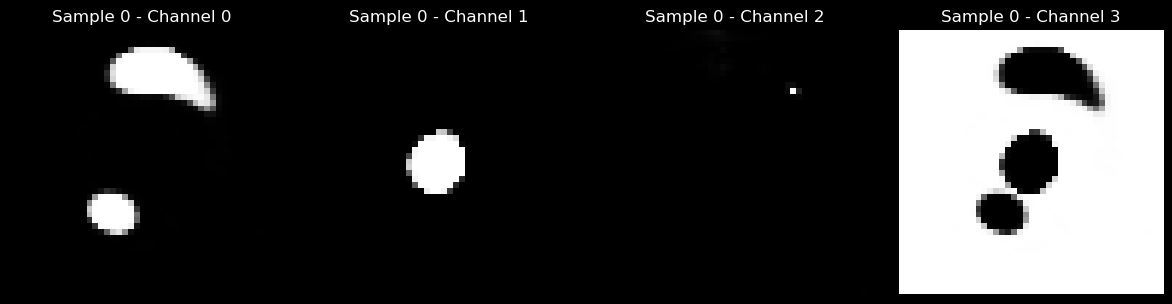

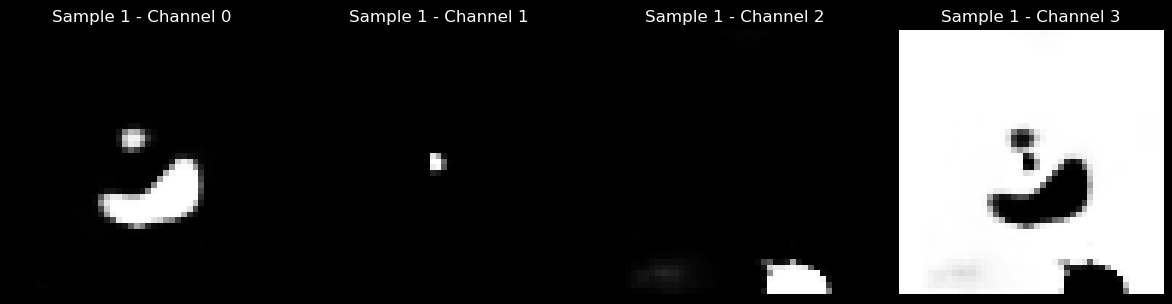

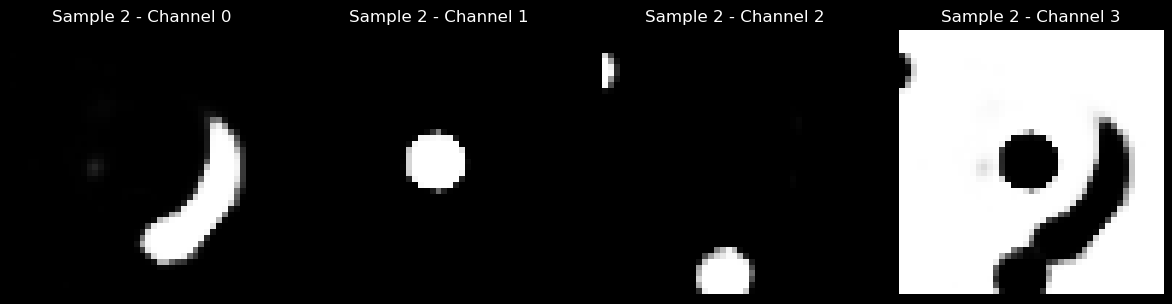

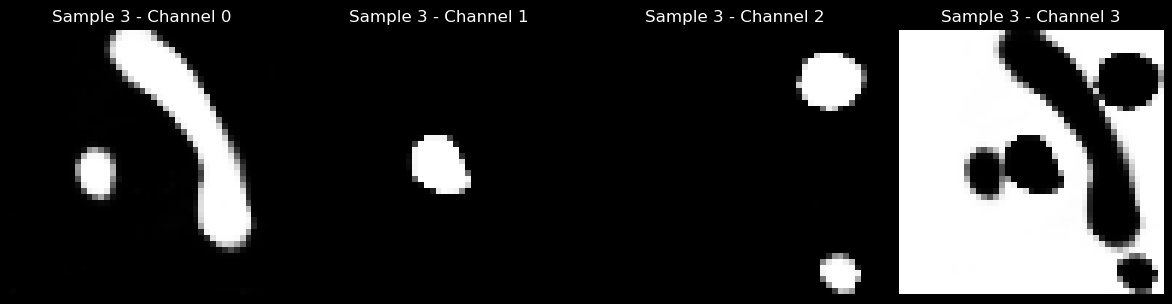

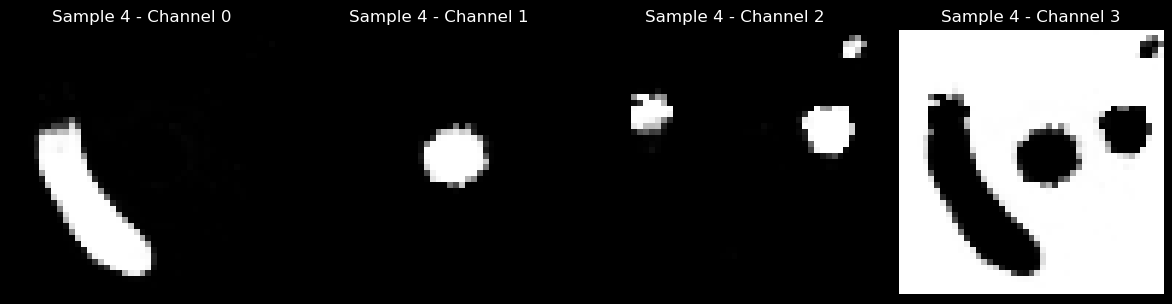

In [14]:
segmented.shape
for i in range(len(segmented)):
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for c in range(4):
        axes[c].imshow(segmented[i][c], cmap='gray')
        axes[c].set_title(f'Sample {i} - Channel {c}')
        axes[c].axis('off')
    plt.tight_layout()
    plt.show()